### Phase 2: Myopic revenue optimization

In this phase, we transition from understanding demand dynamics to actively optimizing pricing decisions. The objective is to identify, at each point in time, the price that maximizes expected revenue given the current observable market conditions.

Unlike Phase 1, which focused on structural validation, this stage adopts a **myopic perspective**: decisions are made to maximize immediate revenue without considering long-term effects or state transitions. This setting is equivalent to a contextual bandit problem, where the environment is treated as static conditional on the observed features.

Formally, at each time step $t$, the goal is to solve:

$$
p_t^* = \arg\max_p \; \mathbb{E}[\text{Revenue}_t \mid X_t, p]
$$

where:
- $p$ is the agent price,
- $X_t$ represents the current state (e.g., seasonality, competitor price),
- revenue is defined as:
$$
\text{Revenue}_t = (p - \text{cost}) \cdot \text{demand}(p, X_t)
$$

Using the demand model estimated in Phase 1 (e.g., via GAM), we approximate the conditional demand function and compute the price that maximizes expected revenue for each observed context.

This phase serves two key purposes:
- Validate that the learned demand model can be used for decision-making;
- Establish a baseline policy before introducing exploration-exploitation trade-offs and dynamic optimization.

By comparing the performance of this myopic policy against the exploratory baseline, we can quantify the gains from leveraging learned demand structure. This also provides a benchmark for more advanced approaches, such as contextual bandits and reinforcement learning, where future states and learning dynamics are explicitly considered.

In [51]:
import pickle
import random
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from functions import MarketPriors
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [52]:
df = pd.read_csv("data/phase_1.csv", parse_dates=["date"])
df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(90, 20)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,price_lag_1,lag_1,log_price,log_comp,state_bin,log_demand,residuals,state_proxy,residuals_2,price_squared
85,2025-03-28,121.440457,128.812906,8.406654e-06,-0.113406,14.904834,715.759816,0.058937,122.370122,0.028706,118.907362,13.795989,-0.104106,-0.065056,"(-0.000999679, 0.000362]",2.701686,-0.246674,-0.272051,0.060384,-0.010838
86,2025-03-29,137.572785,130.031039,2.958194e-06,-0.176007,7.698805,397.217781,-0.056380,128.812906,0.058937,121.440457,14.904834,0.020623,-0.055644,"(-0.000999679, 0.000362]",2.041065,-0.326893,-0.288504,-0.004306,-0.000425
87,2025-03-30,135.538258,132.051480,9.956995e-07,-0.394795,6.949169,324.928128,-0.026062,130.031039,-0.056380,137.572785,7.698805,0.005724,-0.040225,"(-0.000999679, 0.000362]",1.938622,-0.539940,-0.363934,-0.130850,-0.000033
88,2025-03-31,142.179888,138.322897,3.205737e-07,-0.337373,6.561266,339.204082,-0.027502,132.051480,-0.026062,135.538258,6.949169,0.053563,0.006173,"(-0.000999679, 0.000362]",1.881184,-0.478374,-0.398266,-0.023514,-0.002869
89,2025-04-01,133.522361,141.209000,8.713244e-01,-0.356152,16.178875,989.509104,0.055972,138.322897,-0.027502,142.179888,6.561266,-0.009261,0.026824,"(0.755, 1.174]",2.783706,0.066889,-0.258719,0.375999,-0.000086


In [53]:
# =========================================================
# Stable Logistic Demand Model
# =========================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize


# ---------------------------
# 1. Feature engineering
# ---------------------------
def build_features(df):
    df = df.copy()
    
    df["log_price"] = np.log(df["price_agent"] / df["price_agent"].mean())
    df["log_comp"] = np.log(df["price_competitor"] / df["price_competitor"].mean())
    df["log_price_sq"] = df["log_price"] ** 2
    
    return df


# ---------------------------
# 2. Logistic demand function
# ---------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def predict_demand(params, X, D_max):
    z = X @ params
    return D_max * sigmoid(z)


# ---------------------------
# 3. Fit model (MLE-style)
# ---------------------------
def fit_model(df):
    
    X = df[
        [
            "log_price",
            "log_price_sq",
            "log_comp",
            "state_proxy"
        ]
    ].values
    
    X = np.column_stack([np.ones(len(X)), X])
    y = df["realized_demand"].values
    
    D_max = y.max() * 1.1  # upper bound
    
    def loss(params):
        pred = predict_demand(params, X, D_max)
        return np.mean((y - pred) ** 2)
    
    init = np.zeros(X.shape[1])
    
    res = minimize(loss, init, method="L-BFGS-B")
    
    return res.x, D_max


# ---------------------------
# 4. Counterfactual simulation
# ---------------------------
def simulate_counterfactual(df, params, D_max, price_grid, priors):
    
    rows = []
    
    for index, row in df.iterrows():
        
        for p in price_grid:
            
            log_p = np.log(p)
            
            x = np.array([
                1.0,
                log_p,
                log_p**2,
                np.log(row["price_competitor"]),
                row["state_proxy"]
            ])
            
            demand = predict_demand(params, x, D_max)
            
            profit = (p - priors.unit_cost) * demand - priors.fixed_cost
            
            rows.append({
                "date": row["date"],
                "price": p,
                "pred_demand": demand,
                "pred_profit": profit
            })
    
    return pd.DataFrame(rows)


# ---------------------------
# 5. Optimal per day
# ---------------------------
def get_daily_optimal(cf_df):
    
    return (
        cf_df
        .sort_values(["date", "pred_profit"], ascending=[True, False])
        .groupby("date", as_index=False)
        .first()
    )

# ---------------------------
# 6. Evaluate policy
# ---------------------------
def evaluate_policy(df, optimal_df, priors):
    
    df = df.copy()
    
    # actual profit
    df["actual_profit"] = (
        (df["price_agent"] - priors.unit_cost) * df["realized_demand"] - priors.fixed_cost
    )
    
    merged = df.merge(optimal_df, on="date", how="left")
    
    merged["profit_uplift"] = (
        merged["pred_profit"] - merged["actual_profit"]
    )
    
    merged["price_delta"] = (
        merged["price"] - merged["price_agent"]
    )
    
    return merged

# ---------------------------
# 7. Full pipeline
# ---------------------------
def run_pipeline(df):
    
    # 1. Features
    df = build_features(df)
    
    # 2. Fit model
    params, D_max = fit_model(df)
    print(params, D_max)

    priors = MarketPriors()
    
    # 3. Price grid (stay within support)
    price_grid = np.linspace(0, priors.price_max, 60)
    
    # 4. Counterfactual simulation
    cf_df = simulate_counterfactual(
        df,
        params,
        D_max,
        price_grid,
        priors
    )
    
    # 5. Optimal policy (per day)
    optimal_df = get_daily_optimal(cf_df)
    
    # 6. Evaluation
    evaluation = evaluate_policy(df, optimal_df, priors)
    
    return {
        "params": params,
        "D_max": D_max,
        "counterfactuals": cf_df,
        "daily_policy": optimal_df,
        "evaluation": evaluation
    }

In [54]:
opt = run_pipeline(df)
opt["evaluation"].head()

[-1.68636531 -6.09764378  8.35441687  3.15744494  1.60715325] 80.58527918719412


C:\Users\Breno\AppData\Local\Temp\ipykernel_8928\4068736946.py:76: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(p)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,...,state_proxy,residuals_2,price_squared,log_price_sq,actual_profit,price,pred_demand,pred_profit,profit_uplift,price_delta
0,2025-01-02,141.709031,129.677936,0.987371,-0.234124,12.400858,813.262126,-0.088722,120.000000,-0.080043,...,0.301176,-0.023444,-0.002525,0.002525,813.262126,160.0,80.585279,7858.527919,7045.265793,18.290969
1,2025-01-03,128.342253,140.530239,1.055439,-0.047140,28.363354,1738.415547,0.090722,129.677936,-0.088722,...,0.387773,0.050311,-0.002384,0.002384,1738.415547,160.0,80.585279,7858.527919,6120.112372,31.657747
2,2025-01-04,147.231567,141.018853,1.079156,0.077130,19.537507,1504.287387,-0.043113,140.530239,0.090722,...,0.546949,0.159397,-0.007828,0.007828,1504.287387,160.0,80.585279,7858.527919,6354.240531,12.768433
3,2025-01-05,109.368206,148.458743,1.055439,-0.005121,62.672396,2894.023757,0.305587,141.018853,-0.043113,...,0.465069,-0.126095,-0.043602,0.043602,2894.023757,160.0,80.585279,7858.527919,4964.504162,50.631794
4,2025-01-06,144.195409,144.769708,0.987371,-0.051842,18.721857,1376.294420,0.003975,148.458743,0.305587,...,0.487296,0.021632,-0.004575,0.004575,1376.294420,160.0,80.585279,7858.527919,6482.233499,15.804591


In [55]:
print(f"Mean uplift: $ {opt['evaluation'].profit_uplift.mean().round(2)}")
print(f"Total uplift: ${opt['evaluation'].profit_uplift.sum().round(2)}")

opt["evaluation"]["demand_uplift"] = opt["evaluation"]["pred_demand"] - opt["evaluation"]["realized_demand"]

print(f"\nMean uplift: {opt['evaluation'].demand_uplift.mean().round(2)} unities")
print(f"Total uplift: {opt['evaluation'].demand_uplift.sum().round(2)} unities")

Mean uplift: $ 6916.77
Total uplift: $622508.94

Mean uplift: 62.88 unities
Total uplift: 5658.93 unities


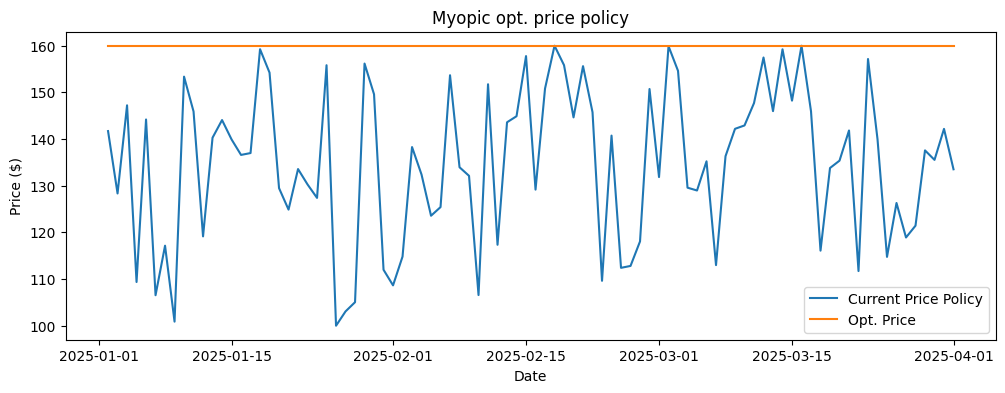

In [56]:
df_plot = opt["evaluation"]

fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(df_plot["date"], df_plot["price_agent"], label="Current Price Policy")
plt.plot(df_plot["date"], df_plot["price"], label="Opt. Price")

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
plt.title("Myopic opt. price policy")

plt.legend()
plt.show()

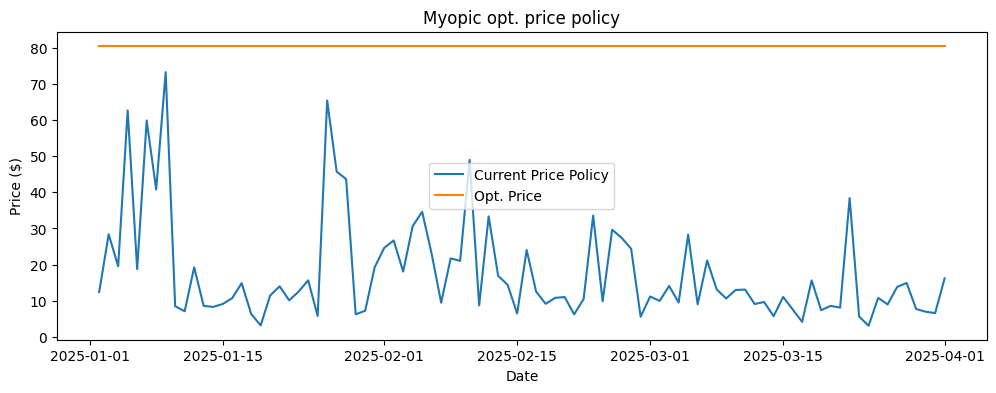

In [57]:

fig, ax = plt.subplots(figsize=(12, 4))
plt.plot(df_plot["date"], df_plot["realized_demand"], label="Current Price Policy")
plt.plot(df_plot["date"], df_plot["pred_demand"], label="Opt. Price")

ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
plt.title("Myopic opt. price policy")

plt.legend()
plt.show()